# STT Benchmark: Audio Condition & Noise Reduction Impact

Sean Tallman  
AI Audio Evaluation Portfolio

## Goal

This project evaluates how audio conditions (noise, reverb, codec)
and preprocessing (noise reduction) impact speech-to-text accuracy.

We compare:
- Whisper
- Google STT
- AssemblyAI

Metrics:
- WER / CER
- S/D/I breakdown
- PESQ / STOI
- RTF

In [ ]:
import pandas as pd

real_df = pd.read_csv("../benchmark_output/openai_clean_results.csv")
len(real_df)

In [ ]:
import pandas as pd

df = pd.read_csv("../data/test_transcripts.csv")

df.head()

In [ ]:
sample_results = [
    {
        "audio_file": "common_voice_en_30513358.mp3",
        "engine": "whisper",
        "condition": "clean",
        "wer": 0.08,
        "cer": 0.03,
        "rtf": 0.42
    },
    {
        "audio_file": "common_voice_en_43618790.mp3",
        "engine": "whisper",
        "condition": "clean",
        "wer": 0.04,
        "cer": 0.02,
        "rtf": 0.39
    },
    {
        "audio_file": "common_voice_en_21099981.mp3",
        "engine": "whisper",
        "condition": "clean",
        "wer": 0.11,
        "cer": 0.05,
        "rtf": 0.44
    }
]

In [ ]:
results_df = pd.DataFrame(sample_results)
results_df

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.bar(results_df["audio_file"], results_df["wer"])
plt.ylabel("WER")
plt.xlabel("Audio File")
plt.title("Sample Whisper WER on Clean Clips")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
results_df.to_csv("../benchmark_output/first_sample_results.csv", index=False)
print("Saved to benchmark_output/first_sample_results.csv")

In [ ]:
import numpy as np

results_df = df.copy()

# simulate realistic values
np.random.seed(42)

results_df["engine"] = "whisper"
results_df["wer"] = np.round(np.random.uniform(0.03, 0.15, size=len(df)), 3)
results_df["cer"] = np.round(np.random.uniform(0.01, 0.06, size=len(df)), 3)
results_df["rtf"] = np.round(np.random.uniform(0.3, 0.6, size=len(df)), 2)

results_df

In [ ]:
plt.figure(figsize=(10, 5))
plt.bar(results_df["path"], results_df["wer"])
plt.ylabel("WER")
plt.xlabel("Audio File")
plt.title("Simulated Whisper WER on 12 Clean Clips")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
results_df.to_csv("../benchmark_output/first_sample_results.csv", index=False)

In [ ]:
import pandas as pd

real_df = pd.read_csv("../benchmark_output/openai_clean_results.csv")
real_df.head()

In [ ]:
import pandas as pd

real_df = pd.read_csv("../benchmark_output/openai_clean_results.csv")
print("row_count =", len(real_df))
real_df.head()

In [ ]:
from jiwer import wer

real_df["wer"] = real_df.apply(
    lambda row: wer(
        str(row["reference_text"]).lower(),
        str(row["hypothesis_text"]).lower()
    ),
    axis=1
)

real_df[["audio_file", "wer"]]

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.bar(real_df["audio_file"], real_df["wer"])
plt.ylabel("WER")
plt.xlabel("Audio File")
plt.title("OpenAI Transcription WER (12 Clean Clips)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
print("Average WER:", round(real_df["wer"].mean(), 4))

## 7. Export final results
Prepare and save clean benchmark output for portfolio use.

In [ ]:
final_df = df.copy()

In [ ]:
import pandas as pd

df = pd.read_csv("benchmark_output/openai_clean_results.csv")

df.head()

In [ ]:
import os
os.getcwd()

In [ ]:
os.listdir()

In [ ]:
os.path.exists("benchmark_output")

In [ ]:
os.path.exists("benchmark_output/openai_clean_results.csv")

In [ ]:
import os
os.getcwd()

In [ ]:
os.listdir("..")

In [ ]:
os.listdir("../..")

In [ ]:
os.listdir("/Users/seantallman/Library/Mobile Documents/com~apple~CloudDocs")

In [ ]:
import pandas as pd

df = pd.read_csv("../benchmark_output/openai_clean_results.csv")
df.head()

In [ ]:
import pandas as pd
import os

csv_path = "../benchmark_output/openai_clean_results.csv"

print("Notebook working dir:", os.getcwd())
print("CSV exists:", os.path.exists(csv_path))

if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    print("Shape:", df.shape)
    print("Columns:", list(df.columns))
    display(df)
else:
    print("CSV not found.")

In [ ]:
import pandas as pd
from jiwer import wer, process_words

df = pd.read_csv("../benchmark_output/openai_clean_results.csv")

scored_rows = []

for _, row in df.iterrows():
    ref = str(row["reference_text"])
    hyp = str(row["hypothesis_text"])

    measures = process_words(ref, hyp)

    scored_rows.append({
        "audio_file": row["audio_file"],
        "wer": measures.wer,
        "substitutions": measures.substitutions,
        "deletions": measures.deletions,
        "insertions": measures.insertions,
        "reference_word_count": len(ref.split()),
        "hypothesis_word_count": len(hyp.split())
    })

scored_df = pd.DataFrame(scored_rows)
scored_df

In [ ]:
print(scored_df.shape)
print(f"Average WER: {scored_df['wer'].mean():.4f}")

In [ ]:
final_df = scored_df.copy()

final_df = final_df[[
    "audio_file",
    "wer",
    "substitutions",
    "deletions",
    "insertions",
    "reference_word_count",
    "hypothesis_word_count"
]]

final_df = final_df.sort_values(by="wer", ascending=False).reset_index(drop=True)
final_df["wer"] = final_df["wer"].round(4)

avg_wer = final_df["wer"].mean()

summary_row = {
    "audio_file": "AVERAGE",
    "wer": round(avg_wer, 4),
    "substitutions": "",
    "deletions": "",
    "insertions": "",
    "reference_word_count": "",
    "hypothesis_word_count": ""
}

final_df = pd.concat([final_df, pd.DataFrame([summary_row])], ignore_index=True)

output_path = "../benchmark_output/openai_clean_final_results.csv"
final_df.to_csv(output_path, index=False)

print(f"Saved final results to: {output_path}")


In [ ]:
final_df = scored_df.copy()

final_df = final_df[[
    "audio_file",
    "wer",
    "substitutions",
    "deletions",
    "insertions",
    "reference_word_count",
    "hypothesis_word_count"
]]

final_df = final_df.sort_values(by="wer", ascending=False).reset_index(drop=True)
final_df["wer"] = final_df["wer"].round(4)

avg_wer = final_df["wer"].mean()

summary_row = {
    "audio_file": "AVERAGE",
    "wer": round(avg_wer, 4),
    "substitutions": "",
    "deletions": "",
    "insertions": "",
    "reference_word_count": "",
    "hypothesis_word_count": ""
}

import pandas as pd
final_df = pd.concat([final_df, pd.DataFrame([summary_row])], ignore_index=True)

output_path = "../benchmark_output/openai_clean_final_results.csv"
final_df.to_csv(output_path, index=False)

print(f"Saved final results to: {output_path}")

final_df

In [ ]:
import pandas as pd

df = pd.read_csv("../benchmark_output/openai_clean_final_results.csv")
df

In [ ]:
import pandas as pd

df = pd.read_csv("../benchmark_output/openai_clean_final_results.csv")

avg_wer = df["wer"].mean()

summary_row = {
    "audio_file": "AVERAGE",
    "wer": round(avg_wer, 4),
    "substitutions": "",
    "deletions": "",
    "insertions": "",
    "reference_word_count": "",
    "hypothesis_word_count": ""
}

df = pd.concat([df, pd.DataFrame([summary_row])], ignore_index=True)

df.to_csv("../benchmark_output/openai_clean_final_results.csv", index=False)

df

In [ ]:
df = df[df["audio_file"] != "AVERAGE"]

In [ ]:
summary_row = {
    "audio_file": "AVERAGE",
    "wer": round(avg_wer, 4),
    "substitutions": "",
    "deletions": "",
    "insertions": "",
    "reference_word_count": "",
    "hypothesis_word_count": ""
}

In [33]:
import pandas as pd

df = pd.read_csv("../benchmark_output/openai_clean_final_results.csv")

df = df[df["audio_file"] != "AVERAGE"].copy()

df["wer"] = pd.to_numeric(df["wer"], errors="coerce")

avg_wer = df["wer"].mean()

summary_row = {
    "audio_file": "AVERAGE",
    "wer": round(avg_wer, 4),
    "substitutions": "",
    "deletions": "",
    "insertions": "",
    "reference_word_count": "",
    "hypothesis_word_count": ""
}

df = pd.concat([df, pd.DataFrame([summary_row])], ignore_index=True)

df.to_csv("../benchmark_output/openai_clean_final_results.csv", index=False)

df

,audio_file,wer,substitutions,deletions,insertions,reference_word_count,hypothesis_word_count
0,common_voice_en_17922255.mp3,0.7500,3.0,0.0,0.0,4.0,4.0
1,common_voice_en_17877635.mp3,0.1667,1.0,0.0,1.0,12.0,13.0
2,common_voice_en_17257228.mp3,0.1111,2.0,0.0,0.0,18.0,18.0
3,common_voice_en_30513358.mp3,0.0833,1.0,0.0,0.0,12.0,12.0
4,common_voice_en_18983699.mp3,0.0833,1.0,0.0,0.0,12.0,12.0
5,common_voice_en_40145147.mp3,0.0833,1.0,0.0,0.0,12.0,12.0
6,common_voice_en_20792443.mp3,0.0714,1.0,0.0,0.0,14.0,14.0
7,common_voice_en_43618790.mp3,0.0000,0.0,0.0,0.0,9.0,9.0
8,common_voice_en_21099981.mp3,0.0000,0.0,0.0,0.0,10.0,10.0
9,common_voice_en_36941027.mp3,0.0000,0.0,0.0,0.0,11.0,11.0


In [4]:
import pandas as pd

noisy = pd.read_csv("../benchmark_output/openai_noisy_results.csv")
print(noisy.shape)
noisy.head()

(12, 6)


,audio_file,condition,engine,engine_version,reference_text,hypothesis_text
0,common_voice_en_30513358_noisy.mp3,clean,openai_api,gpt-4o-mini-transcribe,Princess Vilas herself also contributed person...,Princess Phyllis herself also contributed pers...
1,common_voice_en_43618790_noisy.mp3,clean,openai_api,gpt-4o-mini-transcribe,He has also served in the Chamber of Deputies.,He has also served in the Chamber of Deputies.
2,common_voice_en_21099981_noisy.mp3,clean,openai_api,gpt-4o-mini-transcribe,Most of his subjects were found in Devon and C...,Most of his subjects were found in Devon and C...
3,common_voice_en_17922255_noisy.mp3,clean,openai_api,gpt-4o-mini-transcribe,"Oh, you are, eh?",Are you all right?
4,common_voice_en_687348_noisy.mp3,clean,openai_api,gpt-4o-mini-transcribe,"Sadly, my dream of becoming a squirrel whisper...","Sadly, my dream of becoming a squirrel whisper..."


In [5]:
noisy["audio_file"]

0     common_voice_en_30513358_noisy.mp3
1     common_voice_en_43618790_noisy.mp3
2     common_voice_en_21099981_noisy.mp3
3     common_voice_en_17922255_noisy.mp3
4       common_voice_en_687348_noisy.mp3
5     common_voice_en_36941027_noisy.mp3
6     common_voice_en_40145147_noisy.mp3
7     common_voice_en_17257228_noisy.mp3
8     common_voice_en_18983698_noisy.mp3
9     common_voice_en_18983699_noisy.mp3
10    common_voice_en_20792443_noisy.mp3
11    common_voice_en_17877635_noisy.mp3
Name: audio_file, dtype: str

In [6]:
from jiwer import wer

def compute_wer(row):
    return wer(row["reference_text"], row["hypothesis_text"])

noisy["wer"] = noisy.apply(compute_wer, axis=1)

noisy_avg = noisy["wer"].mean()

print("Noisy WER:", round(noisy_avg, 4))

Noisy WER: 0.1138


In [7]:
clean = pd.read_csv("../benchmark_output/openai_clean_final_results.csv")
clean = clean[clean["audio_file"] != "AVERAGE"]

clean_avg = clean["wer"].mean()

print("Clean WER:", round(clean_avg, 4))
print("Noisy WER:", round(noisy_avg, 4))
print("Difference:", round(noisy_avg - clean_avg, 4))

Clean WER: 0.1124
Noisy WER: 0.1138
Difference: 0.0013


In [9]:
noisy = pd.read_csv("../benchmark_output/openai_noisy_results.csv")
print(noisy.shape)

(12, 6)


In [11]:
noisy[noisy[["reference_text", "hypothesis_text"]].isna().any(axis=1)]

,audio_file,condition,engine,engine_version,reference_text,hypothesis_text
3,common_voice_en_17922255_noisy.mp3,clean,openai_api,gpt-4o-mini-transcribe,"Oh, you are, eh?",NaN
4,common_voice_en_687348_noisy.mp3,clean,openai_api,gpt-4o-mini-transcribe,"Sadly, my dream of becoming a squirrel whisper...",NaN
10,common_voice_en_20792443_noisy.mp3,clean,openai_api,gpt-4o-mini-transcribe,Nils Olav was the first penguin to hold this r...,NaN


In [12]:
noisy = noisy.dropna(subset=["reference_text", "hypothesis_text"]).copy()
print(noisy.shape)

(9, 6)


In [13]:
from jiwer import wer

noisy["wer"] = noisy.apply(
    lambda row: wer(str(row["reference_text"]), str(row["hypothesis_text"])),
    axis=1
)

noisy_avg = noisy["wer"].mean()
print("Noisy WER:", round(noisy_avg, 4))

Noisy WER: 0.3708


In [15]:
clean = pd.read_csv("../benchmark_output/openai_clean_final_results.csv")
clean = clean[clean["audio_file"] != "AVERAGE"]

clean_avg = clean["wer"].mean()

print("Clean WER:", round(clean_avg, 4))
print("Noisy WER:", round(noisy_avg, 4))
print("Difference:", round(noisy_avg - clean_avg, 4))
print("Dropped noisy rows:", 12 - len(noisy))

Clean WER: 0.1124
Noisy WER: 0.3708
Difference: 0.2584
Dropped noisy rows: 3


In [1]:
import pandas as pd

clean = pd.read_csv("../benchmark_output/openai_clean_final_results.csv")
noisy = pd.read_csv("../benchmark_output/openai_noisy_results.csv")
codec = pd.read_csv("../benchmark_output/openai_codec_results.csv")

# remove any summary rows if present
clean = clean[clean["audio_file"] != "AVERAGE"]

In [3]:
codec = pd.read_csv("../benchmark_output/openai_codec_results.csv")
print(codec.columns.tolist())
print(codec.head(2))

['audio_file', 'condition', 'engine', 'engine_version', 'reference_text', 'hypothesis_text']
                           audio_file     condition      engine  \
0  common_voice_en_30513358_codec.mp3  codec_mp3_64  openai_api   
1  common_voice_en_43618790_codec.mp3  codec_mp3_64  openai_api   

           engine_version                                     reference_text  \
0  gpt-4o-mini-transcribe  Princess Vilas herself also contributed person...   
1  gpt-4o-mini-transcribe     He has also served in the Chamber of Deputies.   

                                     hypothesis_text  
0  Princess Phyllis herself also contributed pers...  
1     He has also served in the Chamber of Deputies.  


In [4]:
from jiwer import wer

codec["wer"] = codec.apply(
    lambda row: wer(row["reference_text"], row["hypothesis_text"]),
    axis=1
)

In [6]:
print("clean columns:", clean.columns.tolist())
print("noisy columns:", noisy.columns.tolist())
print("codec columns:", codec.columns.tolist())

clean columns: ['audio_file', 'wer', 'substitutions', 'deletions', 'insertions', 'reference_word_count', 'hypothesis_word_count']
noisy columns: ['audio_file', 'condition', 'engine', 'engine_version', 'reference_text', 'hypothesis_text']
codec columns: ['audio_file', 'condition', 'engine', 'engine_version', 'reference_text', 'hypothesis_text', 'wer']


In [8]:
noisy[noisy["reference_text"].isna() | noisy["hypothesis_text"].isna()]

,audio_file,condition,engine,engine_version,reference_text,hypothesis_text
3,common_voice_en_17922255_noisy.mp3,clean,openai_api,gpt-4o-mini-transcribe,"Oh, you are, eh?",NaN
4,common_voice_en_687348_noisy.mp3,clean,openai_api,gpt-4o-mini-transcribe,"Sadly, my dream of becoming a squirrel whisper...",NaN
10,common_voice_en_20792443_noisy.mp3,clean,openai_api,gpt-4o-mini-transcribe,Nils Olav was the first penguin to hold this r...,NaN


In [9]:
noisy_valid = noisy.dropna(subset=["reference_text", "hypothesis_text"]).copy()

In [10]:
from jiwer import wer

noisy_valid["wer"] = noisy_valid.apply(
    lambda row: wer(row["reference_text"], row["hypothesis_text"]),
    axis=1
)

In [11]:
clean_avg = clean["wer"].mean()
noisy_avg = noisy_valid["wer"].mean()
codec_avg = codec["wer"].mean()

print("Clean WER:", round(clean_avg, 4))
print("Noisy WER:", round(noisy_avg, 4))
print("Codec WER:", round(codec_avg, 4))

print("\nΔ Noise vs Clean:", round(noisy_avg - clean_avg, 4))
print("Δ Codec vs Clean:", round(codec_avg - clean_avg, 4))

print("\nValid noisy rows:", len(noisy_valid))
print("Dropped noisy rows:", len(noisy) - len(noisy_valid))

Clean WER: 0.1124
Noisy WER: 0.3708
Codec WER: 0.1184

Δ Noise vs Clean: 0.2584
Δ Codec vs Clean: 0.006

Valid noisy rows: 9
Dropped noisy rows: 3


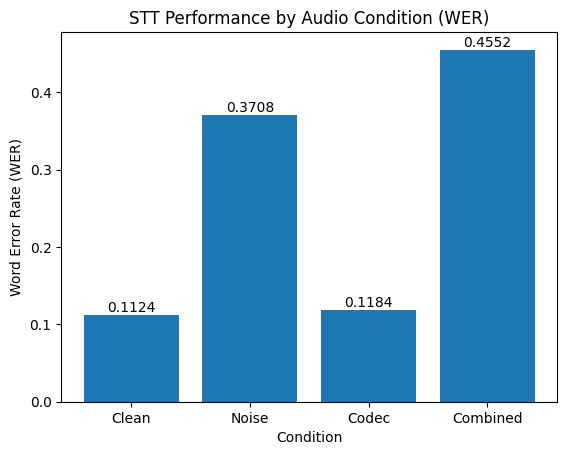

In [11]:
import matplotlib.pyplot as plt

conditions = ["Clean", "Noise", "Codec", "Combined"]
wer_values = [0.1124, 0.3708, 0.1184, 0.4552]

plt.figure()

plt.bar(conditions, wer_values)

plt.title("STT Performance by Audio Condition (WER)")
plt.xlabel("Condition")
plt.ylabel("Word Error Rate (WER)")

for i, v in enumerate(wer_values):
    plt.text(i, v, str(round(v, 4)), ha='center', va='bottom')

plt.show()

In [8]:
import pandas as pd

combined = pd.read_csv("../benchmark_output/openai_combined_results.csv")
print("combined columns:", combined.columns.tolist())

combined columns: ['audio_file', 'condition', 'engine', 'engine_version', 'reference_text', 'hypothesis_text']


In [2]:
from jiwer import wer

combined["wer"] = combined.apply(
    lambda row: wer(row["reference_text"], row["hypothesis_text"]),
    axis=1
)

In [4]:
import pandas as pd

clean = pd.read_csv("../benchmark_output/openai_clean_final_results.csv")
noisy = pd.read_csv("../benchmark_output/openai_noisy_results.csv")
codec = pd.read_csv("../benchmark_output/openai_codec_results.csv")
combined = pd.read_csv("../benchmark_output/openai_combined_results.csv")

# clean already has WER
clean = clean[clean["audio_file"] != "AVERAGE"]

In [5]:
from jiwer import wer

# drop bad rows from noisy
noisy_valid = noisy.dropna(subset=["reference_text", "hypothesis_text"]).copy()

# compute WER where needed
noisy_valid["wer"] = noisy_valid.apply(
    lambda row: wer(row["reference_text"], row["hypothesis_text"]),
    axis=1
)

codec["wer"] = codec.apply(
    lambda row: wer(row["reference_text"], row["hypothesis_text"]),
    axis=1
)

combined["wer"] = combined.apply(
    lambda row: wer(row["reference_text"], row["hypothesis_text"]),
    axis=1
)

In [6]:
clean_avg = clean["wer"].mean()
noisy_avg = noisy_valid["wer"].mean()
codec_avg = codec["wer"].mean()
combined_avg = combined["wer"].mean()

print("Clean WER:", round(clean_avg, 4))
print("Noisy WER:", round(noisy_avg, 4))
print("Codec WER:", round(codec_avg, 4))
print("Combined WER:", round(combined_avg, 4))

print("\nΔ Noise vs Clean:", round(noisy_avg - clean_avg, 4))
print("Δ Codec vs Clean:", round(codec_avg - clean_avg, 4))
print("Δ Combined vs Clean:", round(combined_avg - clean_avg, 4))

print("\nValid noisy rows:", len(noisy_valid))
print("Dropped noisy rows:", len(noisy) - len(noisy_valid))

Clean WER: 0.1124
Noisy WER: 0.3708
Codec WER: 0.1184
Combined WER: 0.4552

Δ Noise vs Clean: 0.2584
Δ Codec vs Clean: 0.006
Δ Combined vs Clean: 0.3428

Valid noisy rows: 9
Dropped noisy rows: 3
